# 04a — Múltipla Escolha (Q17, Q18, Q20, Q21) e Q16 (anomalia)

**Descoberta na inspeção**: Q17, Q18, Q20, Q21 não eram perguntas abertas, e sim seleção múltipla com checkboxes. As respostas armazenadas como texto contêm os rótulos das opções marcadas, separados por vírgula. **Q16 é anômala** — 30 de 32 respostas são literalmente idênticas, sugerindo opção default pré-selecionada que a maioria não alterou.

Este notebook:
1. Parsea cada resposta multiplicando opções canônicas
2. Reporta % de marcação por opção (com IC 95% Wilson)
3. Gera figuras consolidadas para Sec 4 (implementação)
4. Trata Q16 como achado meta — reporta a anomalia como evidência sobre o instrumento

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd()))
import utils as U

U.setup_matplotlib()
TABLES = U.DATA_PROC / "tables"
df = U.load_anonymized()
print(f"N={len(df)}")

N=32


## 1. Definição das opções canônicas por questão

Extraídas por inspeção das respostas. Cada lista preserva a ordem em que aparece no Forms (importante pra ordenação visual).

In [2]:
Q17_OPTIONS = {  # incorporation_open
    "q17_initial_eval": "Avaliação inicial durante a coleta e preparação de dados",
    "q17_continuous_mon": "Monitoramento contínuo durante todo o ciclo de vida do modelo",
    "q17_test_sets": "Conjuntos de testes são aplicados para validar a consistência, completude e precisão dos dados antes de serem usados no treinamento.",
    "q17_no_strategy": "Não existe uma estratégia formal para assegurar a qualidade dos dados durante o desenvolvimento.",
}
Q17_LABELS = {
    "q17_initial_eval": "Avaliação inicial na coleta/preparação",
    "q17_continuous_mon": "Monitoramento contínuo no ciclo de vida",
    "q17_test_sets": "Conjuntos de teste antes do treinamento",
    "q17_no_strategy": "Não há estratégia formal",
}

Q18_OPTIONS = {  # measurement_open
    "q18_ab_tests": "Testes A/B",
    "q18_perf_metrics": "Análise de métricas de performance (ex.: precisão, recall)",
    "q18_manual_review": "Revisão manual dos resultados",
}
Q18_LABELS = {
    "q18_ab_tests": "Testes A/B",
    "q18_perf_metrics": "Métricas de performance",
    "q18_manual_review": "Revisão manual dos resultados",
}

Q20_OPTIONS = {  # documentation_open
    "q20_structured_text": "Linguagem estruturada (texto)",
    "q20_pm_tools": "Ferramentas de Gerenciamento de Projetos (Jira, Trello ou Asana)",
    "q20_central_docs": "Documentação Centralizada (Sistemas como Confluence, Google Docs ou Notion)",
    "q20_alignment_meet": "Reuniões de Alinhamento",
    "q20_periodic_reports": "Relatórios Periódicos",
}
Q20_LABELS = {
    "q20_structured_text": "Linguagem estruturada (texto)",
    "q20_pm_tools": "Gerenciamento de projetos (Jira/etc)",
    "q20_central_docs": "Documentação centralizada (Confluence/etc)",
    "q20_alignment_meet": "Reuniões de alinhamento",
    "q20_periodic_reports": "Relatórios periódicos",
}

Q21_OPTIONS = {  # challenges_open
    "q21_inconsistency": "Inconsistência entre diferentes fontes de dados",
    "q21_incompleteness": "Dados incompletos ou ausentes",
    "q21_no_standard": "Falta de padronização nos formatos de dados",
    "q21_outdated": "Dados desatualizados ou não confiáveis",
    "q21_collection_errors": "Erros introduzidos durante a coleta e processamento",
    "q21_traceability": "Dificuldade na rastreabilidade e versionamento dos dados",
    "q21_no_tools": "Falta de ferramentas adequadas para validação da qualidade dos dados",
}
Q21_LABELS = {
    "q21_inconsistency": "Inconsistência entre fontes",
    "q21_incompleteness": "Dados incompletos/ausentes",
    "q21_no_standard": "Falta de padronização de formato",
    "q21_outdated": "Dados desatualizados/não confiáveis",
    "q21_collection_errors": "Erros na coleta e processamento",
    "q21_traceability": "Dificuldade de rastreabilidade/versionamento",
    "q21_no_tools": "Falta de ferramentas de validação",
}

## 2. Parser — converte texto livre em colunas binárias

In [3]:
def parse_checkboxes(series: pd.Series, options: dict[str, str]) -> tuple[pd.DataFrame, pd.Series]:
    """Pra cada resposta, marca True se cada opção canônica aparece como substring.
    Retorna (df binário, série com texto residual após remover as opções)."""
    binary = pd.DataFrame(index=series.index, columns=list(options.keys()), dtype=bool)
    binary[:] = False
    residual = series.copy()
    for key, label in options.items():
        present = series.fillna("").str.contains(label, regex=False)
        binary[key] = present
        residual = residual.fillna("").str.replace(label, "", regex=False)
    # Limpar pontuação solta
    residual = residual.str.replace(r"^[,\.\s]+|[,\.\s]+$", "", regex=True)
    residual = residual.str.replace(r"^[,\.]\s*", "", regex=True)
    residual = residual.where(residual.str.len() > 2, "")
    return binary, residual


def proportions_with_ci(binary: pd.DataFrame, labels: dict[str, str], n_total: int) -> pd.DataFrame:
    rows = []
    for key in binary.columns:
        successes = int(binary[key].sum())
        lo, hi = U.wilson_ci(successes, n_total)
        rows.append({
            "key": key,
            "label": labels[key],
            "n": successes,
            "pct": successes / n_total * 100,
            "ci_lo": lo * 100,
            "ci_hi": hi * 100,
        })
    return pd.DataFrame(rows).sort_values("pct", ascending=False).reset_index(drop=True)

In [4]:
q17_bin, q17_res = parse_checkboxes(df["incorporation_open"], Q17_OPTIONS)
q18_bin, q18_res = parse_checkboxes(df["measurement_open"], Q18_OPTIONS)
q20_bin, q20_res = parse_checkboxes(df["documentation_open"], Q20_OPTIONS)
q21_bin, q21_res = parse_checkboxes(df["challenges_open"], Q21_OPTIONS)

n_q17 = df["incorporation_open"].notna().sum()
n_q18 = df["measurement_open"].notna().sum()
n_q20 = df["documentation_open"].notna().sum()
n_q21 = df["challenges_open"].notna().sum()

for q, name, n in [(q17_bin, "Q17", n_q17), (q18_bin, "Q18", n_q18),
                    (q20_bin, "Q20", n_q20), (q21_bin, "Q21", n_q21)]:
    print(f"{name}: n={n}, opções marcadas em média = {q.sum(axis=1).mean():.2f}")

Q17: n=32, opções marcadas em média = 1.91
Q18: n=32, opções marcadas em média = 1.75
Q20: n=32, opções marcadas em média = 2.47
Q21: n=32, opções marcadas em média = 3.56


In [5]:
# Texto residual (P13 Slack/P18 No mesmo MR/etc)
for q, name in [(q17_res, "Q17"), (q18_res, "Q18"), (q20_res, "Q20"), (q21_res, "Q21")]:
    nonempty = q[q.str.len() > 0]
    if len(nonempty):
        print(f"=== {name} resíduos ===")
        for idx, txt in nonempty.items():
            print(f"  P{idx:02d}: {txt!r}")

=== Q17 resíduos ===
  P22: 'Nao participei de nenhum diretamente'
=== Q18 resíduos ===
  P13: 'Em um projeto atual, são colocadas todas as métricas obtidas pelos modelos que estão sendo testados em uma planilha e organizamos todas as métricas que estão sendo cabiveis para esse projeto assim como as matrizes de confusão para cada modelo, assim podemos ordenar facilmente entre as métricas que queremos observar (estamos focando mais em Recall por ser um projeto voltado para saúde e assim é necessário ter o minímo de falsos negativos possíveis)'
=== Q20 resíduos ===
  P13: 'Slack'
  P18: 'No mesmo MR'
=== Q21 resíduos ===
  P13: 'Estrutura dos dados, Natureza dos dados'


## 3. Tabelas de proporções com IC 95%

In [6]:
p17 = proportions_with_ci(q17_bin, Q17_LABELS, n_q17)
p18 = proportions_with_ci(q18_bin, Q18_LABELS, n_q18)
p20 = proportions_with_ci(q20_bin, Q20_LABELS, n_q20)
p21 = proportions_with_ci(q21_bin, Q21_LABELS, n_q21)

for name, p in [("Q17 incorporação", p17), ("Q18 medição", p18),
                ("Q20 documentação", p20), ("Q21 desafios", p21)]:
    print(f"\n=== {name} (n={p.iloc[0]['n']/p.iloc[0]['pct']*100:.0f}) ===")
    for _, r in p.iterrows():
        print(f"  {r['label']:<45s} {r['n']:>2}/{int(r['n']/(r['pct']/100)) if r['pct'] else 0:<2} ({r['pct']:>4.0f}%, IC95 {r['ci_lo']:>4.0f}-{r['ci_hi']:>4.0f})")


=== Q17 incorporação (n=32) ===
  Avaliação inicial na coleta/preparação        23/32 (  72%, IC95   55-  84)
  Conjuntos de teste antes do treinamento       18/32 (  56%, IC95   39-  72)
  Monitoramento contínuo no ciclo de vida       16/32 (  50%, IC95   34-  66)
  Não há estratégia formal                       4/32 (  12%, IC95    5-  28)

=== Q18 medição (n=32) ===
  Métricas de performance                       31/32 (  97%, IC95   84-  99)
  Revisão manual dos resultados                 17/32 (  53%, IC95   36-  69)
  Testes A/B                                     8/32 (  25%, IC95   13-  42)

=== Q20 documentação (n=32) ===
  Reuniões de alinhamento                       28/32 (  88%, IC95   72-  95)
  Linguagem estruturada (texto)                 18/32 (  56%, IC95   39-  72)
  Gerenciamento de projetos (Jira/etc)          17/32 (  53%, IC95   36-  69)
  Documentação centralizada (Confluence/etc)    12/32 (  38%, IC95   23-  55)
  Relatórios periódicos                         

## 4. Figuras — implementação (Q17 + Q18) e desafios/documentação (Q20 + Q21)

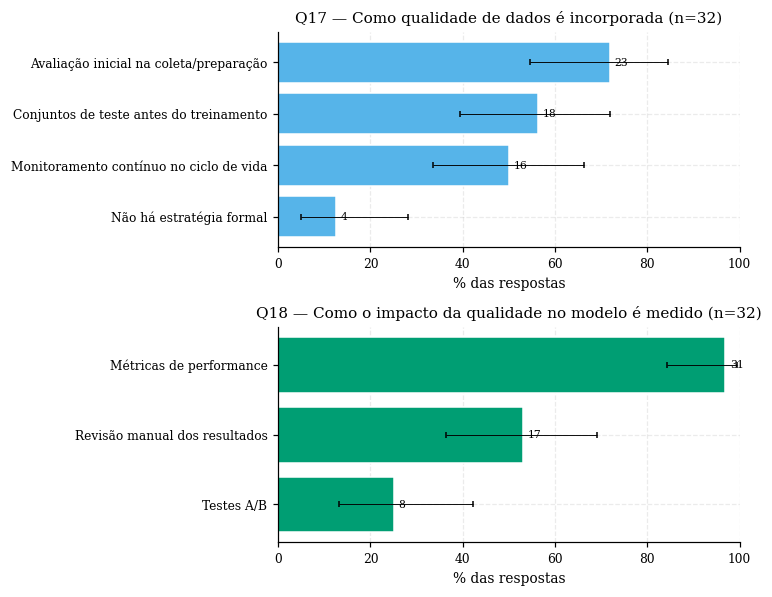

In [7]:
def horizontal_bar(p: pd.DataFrame, title: str, color: str, ax) -> None:
    p_sorted = p.sort_values("pct")
    y = np.arange(len(p_sorted))
    ax.barh(y, p_sorted["pct"], color=color, edgecolor="white")
    # IC 95% como linhas
    ax.errorbar(p_sorted["pct"], y,
                xerr=[p_sorted["pct"] - p_sorted["ci_lo"], p_sorted["ci_hi"] - p_sorted["pct"]],
                fmt="none", ecolor="black", elinewidth=0.6, capsize=2)
    ax.set_yticks(y)
    ax.set_yticklabels(p_sorted["label"])
    ax.set_xlabel("% das respostas")
    ax.set_xlim(0, 100)
    ax.set_title(title)
    for i, (pct, n) in enumerate(zip(p_sorted["pct"], p_sorted["n"])):
        ax.text(pct + 1, i, f"{int(n)}", va="center", fontsize=7)

fig, axes = plt.subplots(2, 1, figsize=(7.0, 5.5))
horizontal_bar(p17, f"Q17 — Como qualidade de dados é incorporada (n={n_q17})", U.PALETTE_WONG[2], axes[0])
horizontal_bar(p18, f"Q18 — Como o impacto da qualidade no modelo é medido (n={n_q18})", U.PALETTE_WONG[3], axes[1])
fig.tight_layout()
U.save_fig(fig, "implementation_q17_q18")
plt.show()

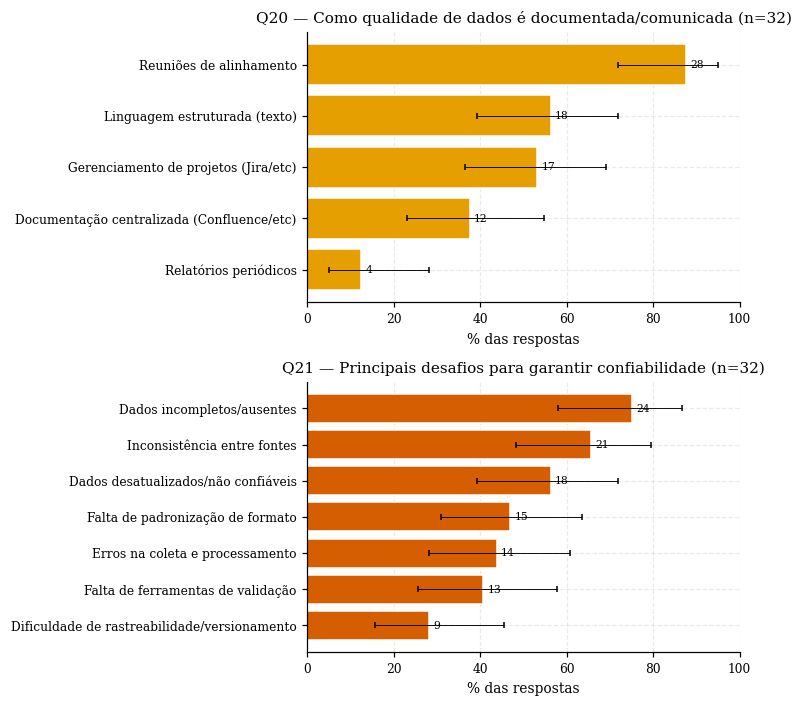

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(7.0, 6.5))
horizontal_bar(p20, f"Q20 — Como qualidade de dados é documentada/comunicada (n={n_q20})", U.PALETTE_WONG[1], axes[0])
horizontal_bar(p21, f"Q21 — Principais desafios para garantir confiabilidade (n={n_q21})", U.PALETTE_WONG[6], axes[1])
fig.tight_layout()
U.save_fig(fig, "challenges_q20_q21")
plt.show()

## 5. Tabela LaTeX consolidada (Q17/Q18/Q20/Q21)

In [9]:
def render_latex(p: pd.DataFrame, label: str, n: int) -> list[str]:
    header = "\\multicolumn{4}{l}{\\textit{" + label + f" (n={n})" + "}} \\\\"
    out = [header]
    for _, r in p.iterrows():
        out.append(f"\\quad {r['label']} & {int(r['n'])} & {r['pct']:.0f}\\% & [{r['ci_lo']:.0f}--{r['ci_hi']:.0f}] \\\\")
    return out

lines = [
    "\\begin{table}[t]",
    "\\caption{Práticas de incorporação, medição, documentação e desafios percebidos. Proporções com IC 95\\% Wilson.}",
    "\\label{tab:implementation}",
    "\\centering",
    "\\small",
    "\\begin{tabular}{lrrr}",
    "\\toprule",
    "\\textbf{Item} & \\textbf{n} & \\textbf{\\%} & \\textbf{IC 95\\%} \\\\",
    "\\midrule",
]
lines.extend(render_latex(p17, "Q17. Incorporação no desenvolvimento", n_q17))
lines.append("\\midrule")
lines.extend(render_latex(p18, "Q18. Medição do impacto no modelo", n_q18))
lines.append("\\midrule")
lines.extend(render_latex(p20, "Q20. Documentação e comunicação", n_q20))
lines.append("\\midrule")
lines.extend(render_latex(p21, "Q21. Desafios para garantir confiabilidade", n_q21))
lines.extend(["\\bottomrule", "\\end{tabular}", "\\end{table}"])
(TABLES / "implementation.tex").write_text("\n".join(lines))
print("[saved] tables/implementation.tex")

[saved] tables/implementation.tex


## 6. Q16 — anomalia como meta-finding

30 de 32 respostas idênticas. As 2 divergentes (P04 e P23) são alternativas semanticamente *erradas*: P04 diz versionamento *elimina* documentação, P23 diz que aumenta dados *sem* checar consistência. Padrão sugere instrumento mal-desenhado: opção tendenciosamente correta como default + distractors raramente escolhidos. Vai pro paper como achado de validade do instrumento, não como evidência substantiva.

In [10]:
q16 = df["versioning_open"].value_counts(dropna=False)
print("=== Q16 distribuição de respostas ===")
for txt, n in q16.items():
    short = (txt[:80] + "...") if isinstance(txt, str) and len(txt) > 80 else txt
    print(f"  {n}× {short!r}")
print(f"\nProporção da resposta dominante: {q16.iloc[0]/len(df)*100:.1f}% (n={q16.iloc[0]}/{len(df)})")

=== Q16 distribuição de respostas ===
  30× 'Garante a consistência e rastreabilidade dos dados ao longo do tempo, permitindo...'
  1× 'Elimina a necessidade de documentar alterações no dataset, pois todas as mudança...'
  1× 'Aumenta a quantidade de dados disponíveis, sem necessidade de verificação de con...'

Proporção da resposta dominante: 93.8% (n=30/32)


## 7. Sumário pra Sec 4 (texto plug-and-play)

In [11]:
import json
summary_implementation = {
    "q17": {"n": int(n_q17), "items": p17.to_dict(orient="records")},
    "q18": {"n": int(n_q18), "items": p18.to_dict(orient="records")},
    "q20": {"n": int(n_q20), "items": p20.to_dict(orient="records")},
    "q21": {"n": int(n_q21), "items": p21.to_dict(orient="records")},
    "q16_anomaly": {
        "n_default": int(q16.iloc[0]),
        "n_total": int(len(df)),
        "pct_default": float(q16.iloc[0] / len(df) * 100),
        "interpretation": ("30/32 respostas idênticas indicam falha de instrumento — "
                            "opção default não removida pelo respondente. Vai pro paper como "
                            "achado meta sobre validação de instrumento, não como evidência substantiva."),
    },
}
(TABLES / "implementation_summary.json").write_text(json.dumps(summary_implementation, ensure_ascii=False, indent=2))
print("[saved] tables/implementation_summary.json")

# Salvar binárias pro replication
all_bin = pd.concat([q17_bin, q18_bin, q20_bin, q21_bin], axis=1)
all_bin.to_csv(U.DATA_PROC / "checkboxes.csv", index_label="respondent_id")
print(f"[saved] data/processed/checkboxes.csv — {all_bin.shape}")

[saved] tables/implementation_summary.json
[saved] data/processed/checkboxes.csv — (32, 19)


## 8. Achados-chave para findings boxes

In [12]:
# Práticas mais e menos adotadas
print("--- Q17 incorporação ---")
print(f"  Mais comum: {p17.iloc[0]['label']} ({p17.iloc[0]['pct']:.0f}%)")
print(f"  Sem estratégia formal: {p17[p17['key']=='q17_no_strategy']['pct'].iloc[0]:.0f}%")

print("--- Q18 medição ---")
print(f"  Mais comum: {p18.iloc[0]['label']} ({p18.iloc[0]['pct']:.0f}%)")
print(f"  Testes A/B: {p18[p18['key']=='q18_ab_tests']['pct'].iloc[0]:.0f}%")

print("--- Q20 documentação ---")
print(f"  Mais comum: {p20.iloc[0]['label']} ({p20.iloc[0]['pct']:.0f}%)")
print(f"  Relatórios periódicos: {p20[p20['key']=='q20_periodic_reports']['pct'].iloc[0]:.0f}%")

print("--- Q21 desafios ---")
for _, r in p21.head(3).iterrows():
    print(f"  {r['label']}: {r['pct']:.0f}% (IC95 {r['ci_lo']:.0f}–{r['ci_hi']:.0f})")

--- Q17 incorporação ---
  Mais comum: Avaliação inicial na coleta/preparação (72%)
  Sem estratégia formal: 12%
--- Q18 medição ---
  Mais comum: Métricas de performance (97%)
  Testes A/B: 25%
--- Q20 documentação ---
  Mais comum: Reuniões de alinhamento (88%)
  Relatórios periódicos: 12%
--- Q21 desafios ---
  Dados incompletos/ausentes: 75% (IC95 58–87)
  Inconsistência entre fontes: 66% (IC95 48–80)
  Dados desatualizados/não confiáveis: 56% (IC95 39–72)
